Parameter c = (-0.715+0.15j) is in the Mandelbrot set.


C:\Users\shujo\AppData\Local\Temp\ipykernel_20180\4108867483.py:23: RuntimeWarning: overflow encountered in square
  Z = Z**2 + c
C:\Users\shujo\AppData\Local\Temp\ipykernel_20180\4108867483.py:23: RuntimeWarning: invalid value encountered in square
  Z = Z**2 + c


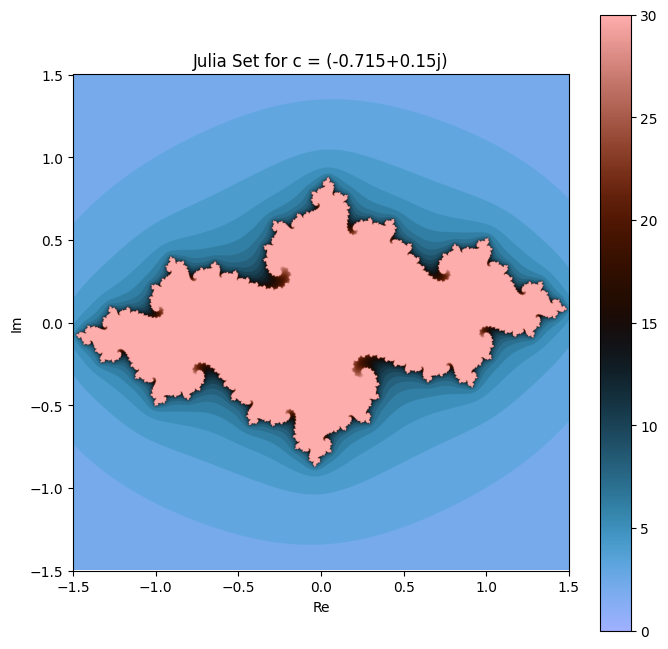

In [3]:
import numpy as np
from cmcrameri import cm
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

def is_in_mandelbrot(c, max_iter=256):
    z = 0
    for i in range(max_iter):
        z = z**2 + c
        if abs(z) > 2:  
            return False
    return True

def julia(c, max_iter, x_min, x_max, y_min, y_max, width, height):

    x, y = np.linspace(x_min, x_max, width), np.linspace(y_min, y_max, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y  

    iteration_counts = np.zeros(Z.shape, dtype=int)

    for i in range(max_iter):
        Z = Z**2 + c  
        mask = np.abs(Z) < 1000  
        iteration_counts[mask] = i  

    return iteration_counts

def plot_julia_for_mandelbrot_c(c, max_iter=256, x_min=-1.5, x_max=1.5, 
    y_min=-1.5,y_max=1.5, width=2000, height=2000, vmin=None, vmax=None):
    
    if is_in_mandelbrot(c):
        print(f"Parameter c = {c} is in the Mandelbrot set.")
        iteration_counts = julia(c, max_iter, x_min, x_max, y_min, y_max, width,
        height)

        if vmin is None:
            vmin = iteration_counts.min()  
        if vmax is None:
            vmax = iteration_counts.max()  

        norm = Normalize(vmin=vmin, vmax=vmax)

        plt.figure(figsize=(8, 8))
        plt.imshow(iteration_counts, cmap='berlin', extent=(x_min, x_max, y_min, 
        y_max), norm=norm)
        plt.colorbar()
        plt.title(f"Julia Set for c = {c}")
        plt.xlabel('Re')
        plt.ylabel('Im')
        plt.show()
    else:
        print(f"Parameter c = {c} is not in the Mandelbrot set.")

c = -0.715 + 0.15j
plot_julia_for_mandelbrot_c(c, vmin=0, vmax=30)